In [1]:
# %%
from mpi4py import MPI
import psutil
import numpy as np
import random as rd
import pickle
import sympy
import copy
import gc
from datetime import datetime

from scipy import sparse
from qiskit_nature.second_q.hamiltonians.lattices import (
    BoundaryCondition,
    Lattice,
    LineLattice,
    SquareLattice
)
from qiskit.quantum_info import SparsePauliOp
from qiskit_nature.second_q.mappers import LogarithmicMapper
from qiskit_nature.second_q.hamiltonians import HeisenbergModel, QuadraticHamiltonian
from qiskit_nature.second_q.circuit.library import BogoliubovTransform


def memory_usage(message: str = 'debug'):
    # this memory_usage function is imported from https://jybaek.tistory.com/895
    # current process RAM usage
    p = psutil.Process()
    rss = p.memory_info().rss / 2 ** 30 # Bytes to GiB
    print(f"[{message}] memory usage: {rss: 10.5f} GiB")


comm = MPI.COMM_WORLD


core = comm.Get_rank()
cores = comm.Get_size()

n_x    = 12
n_site = n_x
n_qubit = n_site
dim = 2**n_qubit


In [2]:
def single_line (lines):
    return ''.join(lines.splitlines())

### XXZ model
$$
    H = -J \sum_{i=1}^{n-1} (S_{i}^{x}S_{i+1}^{x}+S_{i}^{y}S_{i+1}^{y}+\Delta S_{i}^{z}S_{i+1}^{z}) - h \sum_{i=1}^{n} S_i^{z}
$$

In [3]:
J                   = 1.0
h                   = 0.0
bc                  = BoundaryCondition.PERIODIC
lattice  = LineLattice(num_nodes=n_x,boundary_condition=bc)

In [4]:
# construction of quadratic part for even (ndown=nsec=even) and odd parity
lattice = LineLattice(num_nodes=n_x,boundary_condition=bc, edge_parameter=-J/2,\
                        onsite_parameter=h)
quadratic_parts = []
# for an even part
hopping_matrix_even = np.zeros((n_qubit,n_qubit),dtype=complex)
for i_site, j_site, weight in lattice.graph.weighted_edge_list():
    hopping_matrix_even[i_site,j_site] = weight
    hopping_matrix_even[j_site,i_site] = np.conj(weight)
hopping_matrix_even[0,-1] = -hopping_matrix_even[0,-1]
hopping_matrix_even[-1,0] = -hopping_matrix_even[-1,0]
quadratic_part = QuadraticHamiltonian(hermitian_part=hopping_matrix_even)
quadratic_parts.append(quadratic_part)

# for an odd part
hopping_matrix_odd = np.zeros((n_qubit,n_qubit),dtype=complex)
for i_site, j_site, weight in lattice.graph.weighted_edge_list():
    hopping_matrix_odd[i_site,j_site] = weight
    hopping_matrix_odd[j_site,i_site] = np.conj(weight)
quadratic_part = QuadraticHamiltonian(hermitian_part=hopping_matrix_odd)
quadratic_parts.append(quadratic_part)

In [5]:
n_Delta             = 11
Delta_max           = 2.0
Deltas              = np.linspace(0.0,Delta_max,n_Delta)
hamiltonians        = []
mapper = LogarithmicMapper()
for i_Delta in range(n_Delta):
    Delta = Deltas[i_Delta]
    hamiltonian = HeisenbergModel(lattice,coupling_constants=(-J,-J,-J*Delta),ext_magnetic_field=(0,0,-h))
    hamiltonians.append(mapper.map(hamiltonian.second_q_op()))

    if (core==0):
        print(Delta, single_line(str(hamiltonians[i_Delta])))
        print('')

0.0 SparsePauliOp(['IIIIIIIIIIXX', 'IIIIIIIIIIYY', 'IIIIIIIIIXXI', 'IIIIIIIIIYYI', 'IIIIIIIIXXII', 'IIIIIIIIYYII', 'IIIIIIIXXIII', 'IIIIIIIYYIII', 'IIIIIIXXIIII', 'IIIIIIYYIIII', 'IIIIIXXIIIII', 'IIIIIYYIIIII', 'IIIIXXIIIIII', 'IIIIYYIIIIII', 'IIIXXIIIIIII', 'IIIYYIIIIIII', 'IIXXIIIIIIII', 'IIYYIIIIIIII', 'IXXIIIIIIIII', 'IYYIIIIIIIII', 'XXIIIIIIIIII', 'YYIIIIIIIIII', 'XIIIIIIIIIIX', 'YIIIIIIIIIIY'],              coeffs=[-0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j])

0.2 SparsePauliOp(['IIIIIIIIIIXX', 'IIIIIIIIIIYY', 'IIIIIIIIIIZZ', 'IIIIIIIIIXXI', 'IIIIIIIIIYYI', 'IIIIIIIIIZZI', 'IIIIIIIIXXII', 'IIIIIIIIYYII', 'IIIIIIIIZZII', 'IIIIIIIXXIII', 'IIIIIIIYYIII', 'IIIIIIIZZIII', 'IIIIIIXXIIII', 'IIIIIIYYIIII', 'IIIIIIZZIIII', 'IIIIIXXIIIII', 'IIIIIYYIIIII', 'IIIIIZZIIIII', 'I

In [6]:
single_particle_wavefunctions = [None] * 2
single_particle_energies      = [None] * 2
for i_parity in range(2):
    single_particle_wavefunctions[i_parity], single_particle_energies[i_parity], C = quadratic_parts[i_parity].diagonalizing_bogoliubov_transform()
    print(i_parity,single_particle_energies[i_parity])

0 [-0.96592583 -0.96592583 -0.70710678 -0.70710678 -0.25881905 -0.25881905
  0.25881905  0.25881905  0.70710678  0.70710678  0.96592583  0.96592583]
1 [-1.00000000e+00 -8.66025404e-01 -8.66025404e-01 -5.00000000e-01
 -5.00000000e-01 -2.43383172e-16 -1.10133383e-16  5.00000000e-01
  5.00000000e-01  8.66025404e-01  8.66025404e-01  1.00000000e+00]


In [7]:
def generate_numbers_with_ones(n, k):
    if k > n:
        return []
    if k==n:
        return [(1<<n-1)]
    if k==0:
        return [0]
    # Start with the lowest number with exactly k ones (e.g., for n=5, k=2: "00011")
    number = (1 << k) - 1  # All 1s
    m = n-k

    results = []

    # The highest number with n-m ones and m zeros (e.g., for n=5, m=2: "11100")
    limit = (1 << n) - (1 << m)

    while number <= limit:
        # Count 0s to ensure it has exactly m zeros
        binary_str = f'{number:0{n}b}'
        # Check if the binary representation of the number has exactly m zeros
        if binary_str.count('0') == m:
            results.append(number)
        
        # Gosper's hack to get the next combination of (n-m) 1s in an n-bit number
        c = number & -number
        r = number + c
        number = (((r ^ number) >> 2) // c) | r

    return results

# Example usage
digits=n_qubit
numbers_with_m_zeros = generate_numbers_with_ones(digits, digits-1)
#print(numbers_with_m_zeros)

In [8]:
# sectorize
nsec = n_qubit//2+1
dim_sub = [0 for _ in range(nsec)]
indx_sub = [[] for _ in range(nsec)]
iindx_sub = [[] for _ in range(nsec)]

Z_target = [0 for _ in range(nsec)]

for isec in range(nsec):
    Z_target[isec] = (n_qubit-2*isec)

for isec in range(nsec):
    dim_sub[isec] = 0
    indx_sub[isec] = generate_numbers_with_ones(n_qubit,isec)
    dim_sub[isec] = len(indx_sub[isec])
    
    #print(indx_sub[isec])


    if (core==0):
        st = '# dimension of subspace with Z= {Z_target}: {dim_sub}'.format(Z_target=Z_target[isec],dim_sub=dim_sub[isec])
        print(st)
    indx_sub[isec] = np.array(indx_sub[isec])
    # inverse of indx_sub
    #print(indx_sub[isec])
    iindx_sub[isec] = -np.ones((dim),dtype=int)
    for i in range(dim_sub[isec]):
        iindx_sub[isec][indx_sub[isec][i]] = i

# dimension of subspace with Z= 12: 1
# dimension of subspace with Z= 10: 12
# dimension of subspace with Z= 8: 66
# dimension of subspace with Z= 6: 220
# dimension of subspace with Z= 4: 495
# dimension of subspace with Z= 2: 792
# dimension of subspace with Z= 0: 924


In [9]:
print(nsec)

7


In [10]:
#Operator(init_circuits[0]).data

In [11]:
# for a periodic case, only a even solutions are considered.
# Then, degeneracy consideration is not needed, because
# particle is added and removed as pair
nsec_even = nsec//2+1
Sz_list = [(n_qubit/2-isec) for isec in range(nsec)]
# k th element represent particle number n in the Jordan-Wigner
#print(Sz_list)

from qiskit import QuantumCircuit, QuantumRegister
qr = QuantumRegister(n_qubit)
bog_circuit = BogoliubovTransform(single_particle_wavefunctions[0])

init_circuits = [None] * (nsec)
indx_circuit = QuantumCircuit(qr)
for k in range(nsec):
    circuit = indx_circuit.compose(bog_circuit)
    init_circuits[k]=circuit
    #print(circuit)
    indx_circuit.x(qr[k])




#from qiskit.quantum_info import Operator
#H = hamiltonians[0].to_matrix()
##
#Sz_list = []
#for i_site in range(n_site):
#    Sz_list.append(('Z',[i_site],0.5))
#Sz = SparsePauliOp.from_sparse_list(Sz_list,num_qubits=n_qubit)
##print(Sz)
#Szm = Sz.to_matrix()
#Esum = 0.0
#for k in range(0,nsec,2):
#    init_circuit_unitary = np.asarray(Operator(init_circuits[k]).data)
#    M = init_circuit_unitary.conj().T@H@init_circuit_unitary
#    s = init_circuit_unitary.conj().T@Szm@init_circuit_unitary
#    print(M[0,0],Esum, s[0,0], n_qubit//2-k)
#    Esum += single_particle_energies[0][k]*2


In [12]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
sim = AerSimulator()
pass_manager = generate_preset_pass_manager(3,sim)

In [13]:
circuit_opt = pass_manager.run(init_circuits[0])
print(circuit_opt)

global phase: π
        ┌────────┐ ┌───┐┌──────────────┐┌───┐  ┌────────┐                      »
 q0_0: ─┤ U1(-π) ├─┤ X ├┤ Ry(-0.90349) ├┤ X ├──┤ U1(-π) ├──────────────────────»
       ┌┴────────┴┐└─┬─┘├──────────────┤└─┬─┘┌─┴────────┴┐┌───┐┌─────────────┐ »
 q0_1: ┤0         ├──■──┤ Ry(-0.90349) ├──■──┤ U2(-π,-π) ├┤ X ├┤ Ry(-1.1671) ├─»
       │  Unitary │     ├──────────────┤     └───────────┘└─┬─┘├─────────────┤ »
 q0_2: ┤1         ├──■──┤ Ry(-0.44746) ├──■─────────────────■──┤ Ry(-1.1671) ├─»
       ├──────────┤┌─┴─┐├──────────────┤┌─┴─┐ ┌──────────┐     ├─────────────┴┐»
 q0_3: ┤0         ├┤ X ├┤ Ry(-0.44746) ├┤ X ├─┤ U2(0,-π) ├──■──┤ Ry(-0.48019) ├»
       │  Unitary │└───┘├──────────────┤└───┘ ├──────────┤┌─┴─┐├──────────────┤»
 q0_4: ┤1         ├──■──┤ Ry(-0.80755) ├──■───┤ U2(0,-π) ├┤ X ├┤ Ry(-0.48019) ├»
       ├──────────┤┌─┴─┐├──────────────┤┌─┴─┐ ├──────────┤└───┘├──────────────┤»
 q0_5: ┤0         ├┤ X ├┤ Ry(-0.80755) ├┤ X ├─┤ U2(0,-π) ├──■──┤ Ry(-0.67278) ├»
       │  Un

In [14]:
nsec_even = nsec//2+1

In [15]:
for i in range(0,nsec,2):
    print(i)

0
2
4
6


In [16]:
n_hamiltonians = len(hamiltonians)


# exact eigenvalues
eigen_energies_exact   = []
eigen_vectors_exact   = []
for isec in range(nsec):
    eigen_energies_exact.append(np.zeros((n_Delta,dim_sub[isec]),dtype=float))
    eigen_vectors_exact.append(np.zeros((n_Delta,dim_sub[isec],dim_sub[isec]),dtype=complex))

# only consider even sectors
for isec in range(0,nsec,2):
    eigen_e               = np.zeros((dim_sub[isec]),dtype=float)
    eigen_v               = np.zeros((dim_sub[isec],dim_sub[isec]),dtype=complex)
    for alpha in range(n_hamiltonians):
        start_time = datetime.now()
        # project hamiltonian on to specified sector
        H_sparse = hamiltonians[alpha].to_matrix(sparse=True)
        H_sparse.eliminate_zeros()
        jsec = isec
        row      = []
        col      = []
        data     = []
        for ii in range(dim_sub[isec]):
            i = indx_sub[isec][ii]
            for ind in range(H_sparse.indptr[i],H_sparse.indptr[i+1]):
                # j is always in indx_sub[isec], because the Hamiltonian does not mix it
                #print(i,j)
                j = H_sparse.indices[ind]
                jj = iindx_sub[jsec][j]
                row.append(jj)
                col.append(ii)
                #print(ii,jj)
                data.append(H_sparse.data[ind])
        H_sub = sparse.csc_matrix((data, (row, col)), shape=(dim_sub[jsec], dim_sub[isec]))

        # diagonalize sectorized hamiltonian
        eigen_e, eigen_v = np.linalg.eigh(H_sub.toarray())
        #if (isec==nsec-1):
        if (np.abs(Z_target[isec])<1e-10):
            print(alpha, eigen_e[0],eigen_e[1] )
        #    if (alpha==6):
        #        for k in range(dim_sub[isec]):
        #            overlap = eigen_v[:,k].conj()@eigen_vectors_exact[isec][alpha-1,:,0]
        #            print(k,np.abs(overlap)**2,eigen_e[k])
        #
        eigen_energies_exact[isec][alpha,:]   = eigen_e
        eigen_vectors_exact[isec][alpha,:,:] = eigen_v
        end_time = datetime.now()
        elapsed = end_time-start_time
        elapsed = elapsed.total_seconds()
        #if (core==0):
        #    st = '# {percent}%, elapsed time = {elapsed} secs'.format(percent=((alpha+1)/(nt_inter)*100),elapsed=elapsed)
        #    memory_usage(st)

0 -3.8637033051562764 -3.3460652149512335
1 -3.627206206962178 -3.173355902291438
2 -3.416947493080036 -3.030828216931804
3 -3.2365065612422295 -2.923720285620605
4 -3.092367933887921 -2.8615966574531946
5 -3.0 -2.866025403784439
6 -3.021387494141923 -2.9867196503139275
7 -3.2450404893225353 -3.239577013205959
8 -3.5610020576133 -3.559332350758515
9 -3.908183114282566 -3.9074537907678097
10 -4.270574640727768 -4.270197666025808


In [17]:
def ExactGaussian (isec, alpha, eps, beta):
    Vl = copy.deepcopy(eigen_vectors_exact[isec][alpha,:,:])
    evol = np.zeros((dim_sub[isec],dim_sub[isec]),dtype=complex)
    vec = np.zeros((dim_sub[isec]),dtype=float)
    for k in range(dim_sub[isec]):
        vec[k] = np.exp(-0.5 * beta ** 2 * (eigen_energies_exact[isec][alpha,k]-eps)**2)
    exp_d = np.diag(vec)
    evol = Vl@exp_d@Vl.conj().T
    return evol

In [18]:
norms_approximate  = np.ones((nsec,n_hamiltonians),dtype=float)
beta = 0.5
for isec in range(0,nsec,2):
    phi = eigen_vectors_exact[isec][0,:,0]
    for alpha in range(1,n_hamiltonians):
        phi = ExactGaussian(isec,alpha,eigen_energies_exact[isec][alpha,0],beta)@phi
        norms_approximate[isec,alpha] = np.real(phi.conj()@phi)
        if (core==0):
            print(alpha, norms_approximate[isec,alpha])

1 1.0
2 1.0
3 1.0
4 1.0
5 1.0
6 1.0
7 1.0
8 1.0
9 1.0
10 1.0
1 0.9998500892130036
2 0.9993463966406543
3 0.9982594820549203
4 0.9962455596893885
5 0.9927003000988524
6 0.986307448756901
7 0.9740434474742352
8 0.950427670184198
9 0.9084705532245981
10 0.8421530125562057
1 0.9981314420444058
2 0.9925354568940186
3 0.9820648483773712
4 0.9654899549192054
5 0.9408063683884635
6 0.9012710583773275
7 0.8234958572841496
8 0.687058994372302
9 0.507496524147013
10 0.3289861842016653
1 0.9965620843655778
2 0.9872705557106879
3 0.9716582720892106
4 0.949037868710772
5 0.9172838317149904
6 0.8660460559274011
7 0.7575345966423384
8 0.5758190880946649
9 0.36725574474709594
10 0.19715990474348077


In [19]:
norms_exact  = np.ones((nsec,n_hamiltonians),dtype=float)
for isec in range(0,nsec,2):
    phi = eigen_vectors_exact[isec][0,:,0]
    for alpha in range(1,n_hamiltonians):
        coeff = eigen_vectors_exact[isec][alpha,:,0].conj()@phi
        phi = coeff * eigen_vectors_exact[isec][alpha,:,0]
        norms_exact[isec,alpha] = np.real(phi.conj()@phi)
        if (core==0):
            print(alpha, norms_exact[isec,alpha])

1 1.0
2 1.0
3 1.0
4 1.0
5 1.0
6 1.0
7 1.0
8 1.0
9 1.0
10 1.0
1 0.9989868779954253
2 0.9970992168075177
3 0.9933006343937852
4 0.9851122631848549
5 0.9673457960077915
6 0.9351407682801464
7 0.8983666713102068
8 0.8737863657737953
9 0.8613245572296029
10 0.8550969258884621
1 0.9945062751750644
2 0.9869361980270629
3 0.9757338063390871
4 0.9563237463490323
5 0.9084391048324049
6 0.7348413325184564
7 0.5818422596327995
8 0.5524345844899281
9 0.5440342783454336
10 0.54052829400258
1 0.9919649013137725
2 0.9819769066776949
3 0.9681810574010958
4 0.9451879256370578
5 0.8868781057646329
6 0.6280760407098993
7 0.47115358158225035
8 0.4500862745857455
9 0.4442974931038323
10 0.4419366913095356


In [20]:
# save to file
with open('exact.norm.E.save','w') as file_:
    s = '# Delta, norms, E'
    s += '\n'
    file_.write(s)
    for alpha in range(n_Delta):
        ld = Deltas[alpha]
        s = '{:}'.format(ld)
        for isec in range(0,nsec,2):
            s += '  {:.16e}'.format(norms_exact[isec,alpha])
        for isec in range(nsec):
            s += '  {:.16e}'.format(eigen_energies_exact[isec][alpha,0])
        print(s)
        s += '\n'
        file_.write(s)

0.0  1.0000000000000000e+00  1.0000000000000000e+00  1.0000000000000000e+00  1.0000000000000000e+00  0.0000000000000000e+00  0.0000000000000000e+00  -1.9318516525781364e+00  0.0000000000000000e+00  -3.3460652149512340e+00  0.0000000000000000e+00  -3.8637033051562764e+00
0.2  1.0000000000000000e+00  9.9898687799542529e-01  9.9450627517506440e-01  9.9196490131377246e-01  -5.9999999999999998e-01  0.0000000000000000e+00  -2.1370688149375439e+00  0.0000000000000000e+00  -3.2332652977392229e+00  0.0000000000000000e+00  -3.6272062069621782e+00
0.4  1.0000000000000000e+00  9.9709921680751767e-01  9.8693619802706289e-01  9.8197690667769488e-01  -1.2000000000000000e+00  0.0000000000000000e+00  -2.3443544721617440e+00  0.0000000000000000e+00  -3.1367861627490279e+00  0.0000000000000000e+00  -3.4169474930800359e+00
0.6000000000000001  1.0000000000000000e+00  9.9330063439378524e-01  9.7573380633908713e-01  9.6818105740109583e-01  -1.7999999999999998e+00  0.0000000000000000e+00  -2.5550826622519898e

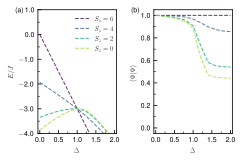

In [21]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size"  : 7
})

cm    = 1.0/2.54
width_col = 8.6*cm
width = width_col
height = width_col/3*2
plt.figure(figsize=(width,height),dpi=600)

cmap = plt.get_cmap('viridis')
colors = [cmap(isec / nsec) for isec in range(nsec)]

marker_style_1  = dict(marker='', linestyle='-', color='tab:red', alpha=0.4,  fillstyle='full')

marker_style_2  = dict(marker='', linestyle='-', color='mediumblue', alpha=0.4,  fillstyle='full')

marker_style_3  = dict(marker='', linestyle='-', color='green', alpha=0.5,  fillstyle='full')

marker_style_4  = dict(marker='', linestyle='-', color='black', alpha=0.5,  fillstyle='full')

marker_style_ref  = dict(marker='', linestyle='-', color='gray', alpha=0.5,  fillstyle='full')

axes = []

ax = plt.subplot2grid((1,2),(0,0))
axes.append(ax)
ax = plt.subplot2grid((1,2),(0,1))
axes.append(ax)

# (a) Energies

axis = axes[0]

y_min    = -4
y_max    = 1.0

x_min    =  -0.05
x_max    =  2.05

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.29,0.98,r'(a)',transform=axis.transAxes)
axis.set_xlabel(r'$\Delta$')
axis.set_ylabel(r'$E/J$')
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))

axis.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# plot
##axes[0].plot(t_exact_2x3, E_exact_2x3, label='', **marker_style_ref)
##axes[0].plot(t_2x3,E_2x3, label='', markersize=4, **marker_style_1)
for isec in range(0,nsec,2):
    color = colors[isec]
    axis.plot(Deltas,eigen_energies_exact[isec][:,0],
              label=fr'$S_z={Z_target[isec]//2}$', lw=1, marker='', linestyle='--',
              color=color, alpha=0.8)
#axis.axvline(x=1.0, label='', **marker_style_ref)


axis.legend(loc='upper right',frameon=False,bbox_to_anchor=(1.10, 1))


# (b) norms
axis = axes[1]

y_min    = -0.05
y_max    = 1.05

x_min    =  -0.05
x_max    =  2.05

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.29,0.98,r'(b)',transform=axis.transAxes)
axis.set_xlabel(r'$\Delta$')
axis.set_ylabel(r'$\langle\Psi|\Psi\rangle$')
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))

axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
##axes[0].plot(t_exact_2x3, E_exact_2x3, label='', **marker_style_ref)
##axes[0].plot(t_2x3,E_2x3, label='', markersize=4, **marker_style_1)
for isec in range(0,nsec,2):
    color = colors[isec]
    axis.plot(Deltas,norms_exact[isec,:],
              label=fr'$S_z={Z_target[isec]//2}$', lw=1, marker='', linestyle='--',
              color=color,alpha=0.8)
#
#
#
#
#
#axis.legend(loc='lower left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.savefig('fig4.pdf')